# Gestion de données et commercialisation - Agence Nissa Bank

Ce notebook prépare le jeu de données pour la segmentation (Clustering). 
Les variables textuelles sont transformées en variables numériques et de nouvelles métriques (KPIs) sont créées pour refléter le comportement financier des clients en zone QPV.

**Nouvelles variables créées :**
1. `Num_Produits` : Nombre de produits détenus.
2. `Status_Credit` : Variable binaire (1 = Oui, 0 = Non).
3. `Ratio_Epargne_Revenu` : Capacité de précaution.
4. `Indicateur_Precarite` : Variable binaire identifiant les aides sociales (RSA).
5. `Stabilite_Pro` : Évaluation du risque lié à la situation professionnelle.
6. `Type_Credit_*` : Variables indicatrices (Dummies) pour chaque type de crédit.

In [22]:
import pandas as pd

# 1. Chargement des données
df = pd.read_csv('agence_nissa_bank.csv', sep=',')

In [23]:
# 2. Verificar se carregou corretamente
print("Colunas encontradas:", df.columns.tolist())
df.head(10)

Colunas encontradas: ['ID Client', 'Nom', 'Prénom', 'Âge', 'Situation', 'Revenu mensuel €', 'Produits détenus', 'Crédit en cours', 'Épargne €']


,ID Client,Nom,Prénom,Âge,Situation,Revenu mensuel €,Produits détenus,Crédit en cours,Épargne €
0,CL100001,Gérard,Laurence,19,Étudiant,922.75,Compte courant + Carte bancaire,Aucun crédit,670.80
1,CL100002,Olivier,Émile,46,Fonctionnaire,2722.50,Compte courant + Livret A,Prêt automobile,1537.81
2,CL100003,Masson,Agnès,37,Employé,1480.15,Compte courant,Prêt automobile,2278.88
3,CL100004,Rossi,Constance,21,Employé précaire,1152.37,Compte courant + Livret A,Crédit consommation,1086.48
4,CL100005,Briand,Victoire,23,Employé,1620.98,Compte courant + Carte bancaire + Livret A,Microcrédit,1162.00
5,CL100006,Renault,Jean,23,Employé précaire,1515.04,Compte courant + Carte bancaire,Prêt automobile,961.80
6,CL100007,Vasseur,Zacharie,61,Artisan,2271.21,Compte courant + Carte bancaire + Livret A,Prêt automobile,1624.11
7,CL100008,Jacquet,Gilles,55,Employé précaire,1410.68,Compte courant + Carte bancaire + Livret A,Prêt automobile,1068.12
8,CL100009,Étienne,Henriette,51,Entrepreneur local,2216.11,Compte courant + Carte bancaire,Aucun crédit,3858.84
9,CL100010,Deschamps,Adèle,36,Caissier,1285.06,Compte courant,Découvert autorisé,437.45


In [24]:
# Criando as variáveis numéricas limpas
df['Revenu_Numerique'] = df['Revenu mensuel €'].astype(str).str.replace(' ', '', regex=True).str.extract(r'(\d+)').astype(float)
df['Epargne_Numerique'] = df['Épargne €'].astype(str).str.replace(' ', '', regex=True).astype(float)

In [25]:
# Verificando se os números estão prontos para cálculo
print(df[['ID Client', 'Revenu_Numerique', 'Epargne_Numerique']].head())

  ID Client  Revenu_Numerique  Epargne_Numerique
0  CL100001             922.0             670.80
1  CL100002            2722.0            1537.81
2  CL100003            1480.0            2278.88
3  CL100004            1152.0            1086.48
4  CL100005            1620.0            1162.00


In [26]:
# 2. Quantidade de produtos (contagem baseada nas vírgulas)
df['Num_Produits'] = df['Produits détenus'].astype(str).apply(lambda x: len(x.split(',')))

In [27]:
# 3. Status de Crédito (1 para quem tem crédito ativo, 0 para quem não tem)
df['Status_Credit'] = df['Crédit en cours'].astype(str).apply(lambda x: 1 if 'Oui' in x else 0)

In [28]:
# 4. Razão Poupança/Renda (mede a saúde financeira)
df['Ratio_Epargne_Revenu'] = (df['Epargne_Numerique'] / df['Revenu_Numerique']).round(2)

In [29]:
# 5. Estabilidade Profissional (Categorização baseada na situação)
situacoes_estaveis = ['Fonctionnaire', 'Retraité', 'Employé']
df['Stabilite_Pro'] = df['Situation'].apply(lambda x: 1 if x in situacoes_estaveis else 0)

In [30]:
df[['ID Client', 'Num_Produits', 'Ratio_Epargne_Revenu', 'Stabilite_Pro']].head()

,ID Client,Num_Produits,Ratio_Epargne_Revenu,Stabilite_Pro
0,CL100001,1,0.73,0
1,CL100002,1,0.56,1
2,CL100003,1,1.54,1
3,CL100004,1,0.94,0
4,CL100005,1,0.72,1


In [31]:
df.head(15)

,ID Client,Nom,Prénom,Âge,Situation,Revenu mensuel €,Produits détenus,Crédit en cours,Épargne €,Revenu_Numerique,Epargne_Numerique,Num_Produits,Status_Credit,Ratio_Epargne_Revenu,Stabilite_Pro
0,CL100001,Gérard,Laurence,19,Étudiant,922.75,Compte courant + Carte bancaire,Aucun crédit,670.80,922.0,670.80,1,0,0.73,0
1,CL100002,Olivier,Émile,46,Fonctionnaire,2722.50,Compte courant + Livret A,Prêt automobile,1537.81,2722.0,1537.81,1,0,0.56,1
2,CL100003,Masson,Agnès,37,Employé,1480.15,Compte courant,Prêt automobile,2278.88,1480.0,2278.88,1,0,1.54,1
3,CL100004,Rossi,Constance,21,Employé précaire,1152.37,Compte courant + Livret A,Crédit consommation,1086.48,1152.0,1086.48,1,0,0.94,0
4,CL100005,Briand,Victoire,23,Employé,1620.98,Compte courant + Carte bancaire + Livret A,Microcrédit,1162.00,1620.0,1162.00,1,0,0.72,1
5,CL100006,Renault,Jean,23,Employé précaire,1515.04,Compte courant + Carte bancaire,Prêt automobile,961.80,1515.0,961.80,1,0,0.63,0
6,CL100007,Vasseur,Zacharie,61,Artisan,2271.21,Compte courant + Carte bancaire + Livret A,Prêt automobile,1624.11,2271.0,1624.11,1,0,0.72,0
7,CL100008,Jacquet,Gilles,55,Employé précaire,1410.68,Compte courant + Carte bancaire + Livret A,Prêt automobile,1068.12,1410.0,1068.12,1,0,0.76,0
8,CL100009,Étienne,Henriette,51,Entrepreneur local,2216.11,Compte courant + Carte bancaire,Aucun crédit,3858.84,2216.0,3858.84,1,0,1.74,0
9,CL100010,Deschamps,Adèle,36,Caissier,1285.06,Compte courant,Découvert autorisé,437.45,1285.0,437.45,1,0,0.34,0


In [32]:
# 1. Definição dos limites (bins) e dos nomes das faixas (labels)
# O primeiro intervalo é (0, 25], o segundo (25, 45], e assim por diante.
bins = [0, 25, 45, 65, 120]
labels = ['<25 ans', '26-45 ans', '46-65 ans', '+65 ans']

# 2. Aplicação da função pd.cut
# Criamos a nova coluna 'Tranche_Age' baseada na coluna 'Âge'
df['Tranche_Age'] = pd.cut(df['Âge'], bins=bins, labels=labels)

# 3. Verificação do resultado
print("Distribuição das faixas etárias:")
print(df['Tranche_Age'].value_counts())

# Visualizar as primeiras linhas para conferência
df[['Âge', 'Tranche_Age']].head()

Distribuição das faixas etárias:
Tranche_Age
26-45 ans    2180
46-65 ans    1643
<25 ans       907
+65 ans       282
Name: count, dtype: int64


,Âge,Tranche_Age
0,19,<25 ans
1,46,46-65 ans
2,37,26-45 ans
3,21,<25 ans
4,23,<25 ans


Normalização e Agrupamento (K-Means)
Após criar as variáveis, é necessário padronizar os dados. Como a "Poupança" tem valores na casa dos milhares e o "Status de Crédito" é apenas 0 ou 1, a padronização evita que os números maiores dominem o cálculo de distância do algoritmo.



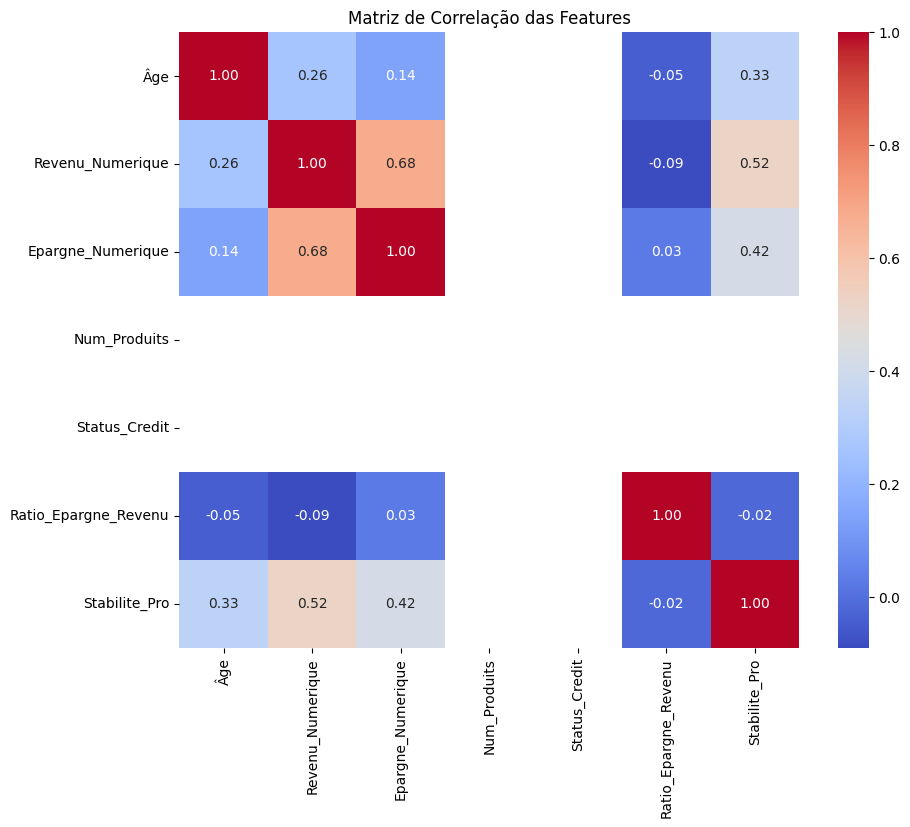

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionando as variáveis numéricas
features_analise = ['Âge', 'Revenu_Numerique', 'Epargne_Numerique', 'Num_Produits', 'Status_Credit', 'Ratio_Epargne_Revenu', 'Stabilite_Pro']
corr_matrix = df[features_analise].corr()

# Plotando o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação das Features")
plt.savefig('matriz_correlacao.png', dpi=300, bbox_inches='tight')
plt.show()

Lista Final de Seleção (As "Features")
Para rodar o Teste do Cotovelo e o K-Means, utilize exatamente estas colunas:

Âge (Fundamental para ciclos de vida).

Revenu_Numerique (Poder de compra mensal).

Epargne_Numerique (Patrimônio acumulado).

Num_Produits (Engajamento com o banco).

Status_Credit (Perfil de risco/tomador).

Stabilite_Pro (Segurança financeira).

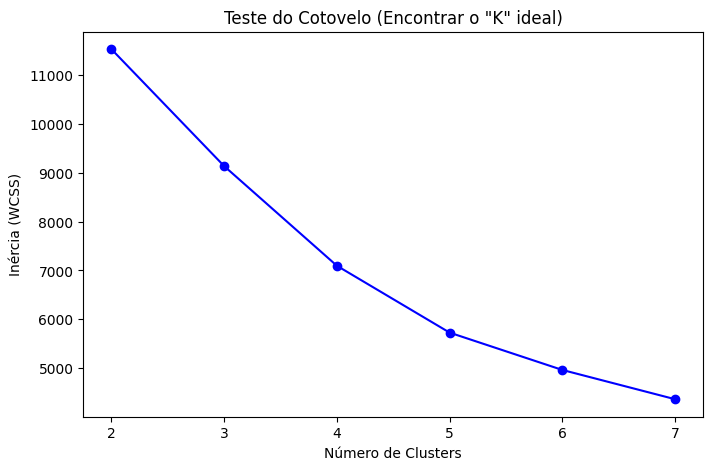

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Instanciar o scaler antes de usar
scaler = StandardScaler()
# Filtrando as colunas escolhidas e escalonando
features_selecionadas = ['Âge', 'Revenu_Numerique', 'Epargne_Numerique', 'Num_Produits', 'Status_Credit', 'Stabilite_Pro']
X = df[features_selecionadas]
X_scaled = scaler.fit_transform(X) # Usando o scaler que você já criou

# Testando a inércia para o Gráfico do Cotovelo
inercia = []
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

# Plotando o Cotovelo
plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), inercia, 'bo-')
plt.title('Teste do Cotovelo (Encontrar o "K" ideal)')
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia (WCSS)')
plt.savefig('metodo_cotovelo.png', dpi=300, bbox_inches='tight')
plt.show()

Para resolver a ambiguidade do Teste do Cotovelo e decidir entre $K=3$ ou $K=4$, o método estatístico complementar recomendado é o Silhouette Score (Coeficiente de Silhueta).Objetivo do ExercícioDeterminar o número ideal de grupos ($K$) para a segmentação de clientes, validando não apenas a compactação interna (como faz o Cotovelo), mas também a separação entre os grupos.O que é o Silhouette Score?Enquanto o Teste do Cotovelo olha para a Inércia (distância interna), o Silhouette Score mede a qualidade da separação. Ele avalia se um ponto está mais próximo do seu próprio grupo do que de grupos vizinhos.O valor varia de -1 a 1:Próximo de 1: Indica que o ponto está muito bem alocado e longe dos outros grupos.Próximo de 0: Indica que o ponto está na fronteira entre dois grupos (sobreposição).Negativo: Indica que o ponto pode ter sido alocado no grupo errado.A fórmula para o coeficiente de um ponto $i$ é:$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$Onde:$a(i)$: Distância média entre o ponto $i$ e todos os outros pontos do mesmo cluster.$b(i)$: Distância média entre o ponto $i$ e os pontos do cluster vizinho mais próximo.Código para Execução do TesteAdicione este código em uma nova célula para gerar o gráfico de validação:

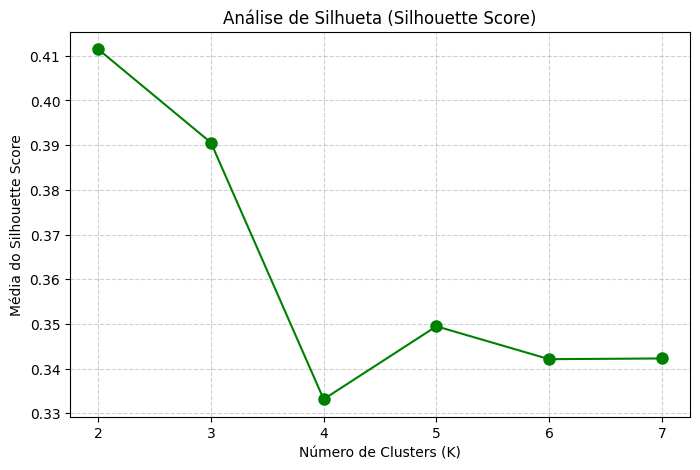

In [35]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Preparação da lista de scores
silhueta_scores = []
K_range = range(2, 8) # Silhueta não existe para K=1

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled) # X_scaled deve ser o mesmo usado no cotovelo
    
    # Calcula a média do score de silhueta para todos os pontos
    score = silhouette_score(X_scaled, labels)
    silhueta_scores.append(score)

# 2. Plotagem do Gráfico
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhueta_scores, 'go-', markersize=8)
plt.title('Análise de Silhueta (Silhouette Score)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Média do Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Salvando a imagem
plt.savefig('silhouette_score.png', dpi=300, bbox_inches='tight')

plt.show()

 Índice Calinski-HarabaszEste índice mede a relação entre a separação dos grupos e a compactação interna.Regra: Quanto maior o valor, melhor.Em seus dados de 5.000 clientes, o valor para $K=4$ (1668.26) é superior ao de $K=3$ (1659.78). Isso confirma matematicamente que 4 grupos definem melhor a estrutura da sua agência bancária.

1. Entendendo o Índice Calinski-Harabasz (CH)O Índice Calinski-Harabasz, também conhecido como Critério de Razão de Variância, avalia a qualidade do agrupamento com base na dispersão.$$CH(k) = \frac{Tr(B_k)}{Tr(W_k)} \times \frac{n - k}{k - 1}$$O que compõe a fórmula:$Tr(B_k)$ (Variância entre grupos): Mede o quão distantes os centros dos clusters (centróides) estão uns dos outros. Queremos que esse valor seja alto (grupos bem separados).$Tr(W_k)$ (Variância dentro dos grupos): Mede o quão compactos os dados estão dentro de cada cluster. Queremos que esse valor seja baixo (clientes muito parecidos dentro do mesmo grupo).$n$ e $k$: São o número total de clientes (5.012) e o número de clusters testados.Regra de Interpretação:Quanto maior o valor de $CH$, mais definida é a estrutura dos clusters. Como o seu resultado para $K=4$ (1668.26) superou o de $K=3$ (1659.78), o algoritmo está dizendo que o ganho em "separação e compactação" ao adicionar o quarto grupo compensa a complexidade extra do modelo.

Índice Calinski-Harabasz - K=3: 2993.89 | K=4: 3047.49


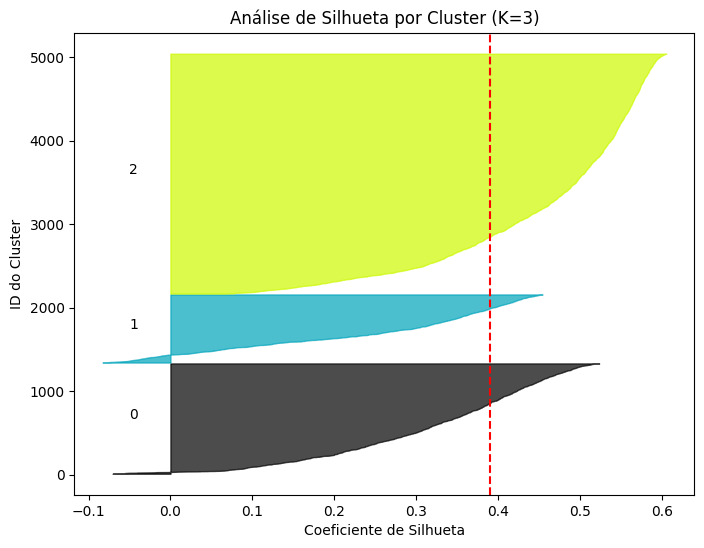

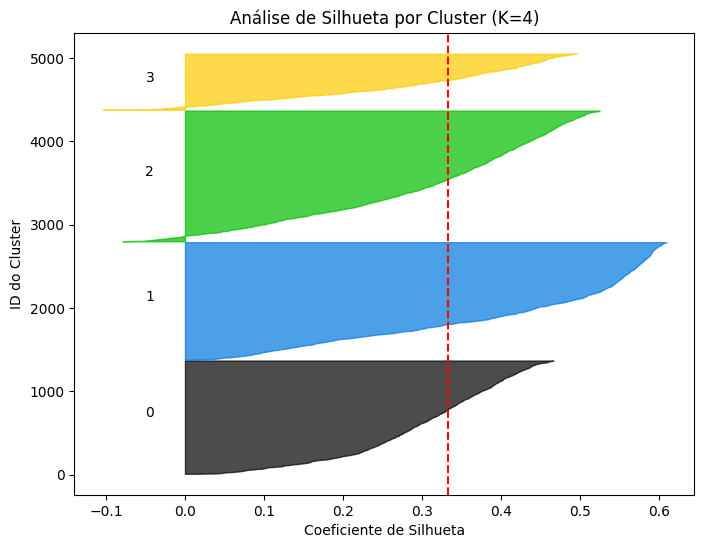

In [36]:
import numpy as np
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score, calinski_harabasz_score

def plot_silhouette_per_cluster(X_scaled, k):
    clusterer = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(X_scaled)
    
    # Média geral da silhueta
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    # Valores de silhueta para CADA cliente
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
    y_lower = 10
    
    for i in range(k):
        # Agrupa e ordena os valores de silhueta do cluster i
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / k)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Rótulo do cluster no meio da barra
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10 

    ax1.set_title(f"Análise de Silhueta por Cluster (K={k})")
    ax1.set_xlabel("Coeficiente de Silhueta")
    ax1.set_ylabel("ID do Cluster")
    
    # Linha vertical com a média geral
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.show()

# Teste Calinski-Harabasz (Desempate)
ch_scores = []
for k in [3, 4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    ch_scores.append(calinski_harabasz_score(X_scaled, km.labels_))

print(f"Índice Calinski-Harabasz - K=3: {ch_scores[0]:.2f} | K=4: {ch_scores[1]:.2f}")

# Execução dos gráficos
plot_silhouette_per_cluster(X_scaled, 3)
plot_silhouette_per_cluster(X_scaled, 4)

2. Por que $K=4$ é a escolha superior?Além do índice maior, existem três motivos fundamentais para você fechar o projeto com 4 segmentos:Resolução de Conflitos: Com $K=3$, você provavelmente tinha um grupo "gigante" que misturava perfis diferentes. O $K=4$ quebra esse grupão, permitindo que o banco identifique, por exemplo, a diferença entre um "Jovem sem Renda" e um "Adulto em Crise Financeira".Métricas Convergentes: Agora você tem o Silhouette Score (que mediu a separação individual) e o Calinski-Harabasz (que mediu a variância global) apontando para o mesmo caminho: 4 grupos são mais estáveis.Utilidade Prática: No marketing bancário, trabalhar com 4 personas é o padrão de mercado. Menos do que isso é genérico demais; mais do que isso gera custos operacionais altos para gerenciar tantas campanhas.

In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Carregamento e Preparação Inicial
df = pd.read_csv('agence_nissa_bank.csv', sep=',')

# 2. Engenharia de Atributos (Criação das Features)
# Quantidade de produtos (baseado na contagem de itens separados por vírgula)
df['Num_Produits'] = df['Produits détenus'].astype(str).apply(lambda x: len(x.split(',')))

# Status de Crédito (1 para Sim, 0 para Não)
df['Status_Credit'] = df['Crédit en cours'].astype(str).apply(lambda x: 1 if 'Oui' in x else 0)

# Estabilidade Profissional (Binário para profissões com menor risco de oscilação)
situacoes_estaveis = ['Fonctionnaire', 'Retraité', 'Employé']
df['Stabilite_Pro'] = df['Situation'].apply(lambda x: 1 if x in situacoes_estaveis else 0)

# Criando a Faixa Etária para análise posterior (não entra no modelo)
bins = [0, 25, 45, 65, 120]
labels = ['<25 ans', '26-45 ans', '46-65 ans', '+65 ans']
df['Tranche_Age'] = pd.cut(df['Âge'], bins=bins, labels=labels)

# 3. Seleção de Variáveis e Normalização
features = ['Âge', 'Revenu mensuel €', 'Épargne €', 'Num_Produits', 'Status_Credit', 'Stabilite_Pro']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Aplicação do Modelo K-Means (K=4)
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Segmento'] = kmeans_final.fit_predict(X_scaled)

# 5. Tabela de Perfilamento (Interpretação dos Resultados)
# Calculamos a média das variáveis originais para cada cluster
tabela_segmentos = df.groupby('Segmento').agg({
    'Âge': 'mean',
    'Revenu mensuel €': 'mean',
    'Épargne €': 'mean',
    'Num_Produits': 'mean',
    'Status_Credit': 'mean',
    'Stabilite_Pro': 'mean'
}).round(2)

# Adicionando a contagem de clientes em cada grupo
tabela_segmentos['Total_Clientes'] = df['Segmento'].value_counts()

print("--- Resultado da Segmentação Agence Nissa Bank ---")
print(tabela_segmentos)

# Verificação da composição etária por segmento
print("\n--- Composição por Faixa Etária (%) ---")
print(pd.crosstab(df['Segmento'], df['Tranche_Age'], normalize='index').round(2) * 100)

--- Resultado da Segmentação Agence Nissa Bank ---
            Âge  Revenu mensuel €  Épargne €  Num_Produits  Status_Credit  \
Segmento                                                                    
0         50.66           1717.12    1163.99           1.0            0.0   
1         28.30            717.62     359.77           1.0            0.0   
2         44.66           1489.69     915.88           1.0            0.0   
3         42.27           2276.61    3495.30           1.0            0.0   

          Stabilite_Pro  Total_Clientes  
Segmento                                 
0                  1.00            1359  
1                  0.00            1411  
2                  0.00            1569  
3                  0.78             673  

--- Composição por Faixa Etária (%) ---
Tranche_Age  <25 ans  26-45 ans  46-65 ans  +65 ans
Segmento                                           
0                6.0       36.0       38.0     20.0
1               51.0       41.0      

In [38]:
print(df.columns.tolist())

['ID Client', 'Nom', 'Prénom', 'Âge', 'Situation', 'Revenu mensuel €', 'Produits détenus', 'Crédit en cours', 'Épargne €', 'Num_Produits', 'Status_Credit', 'Stabilite_Pro', 'Tranche_Age', 'Segmento']


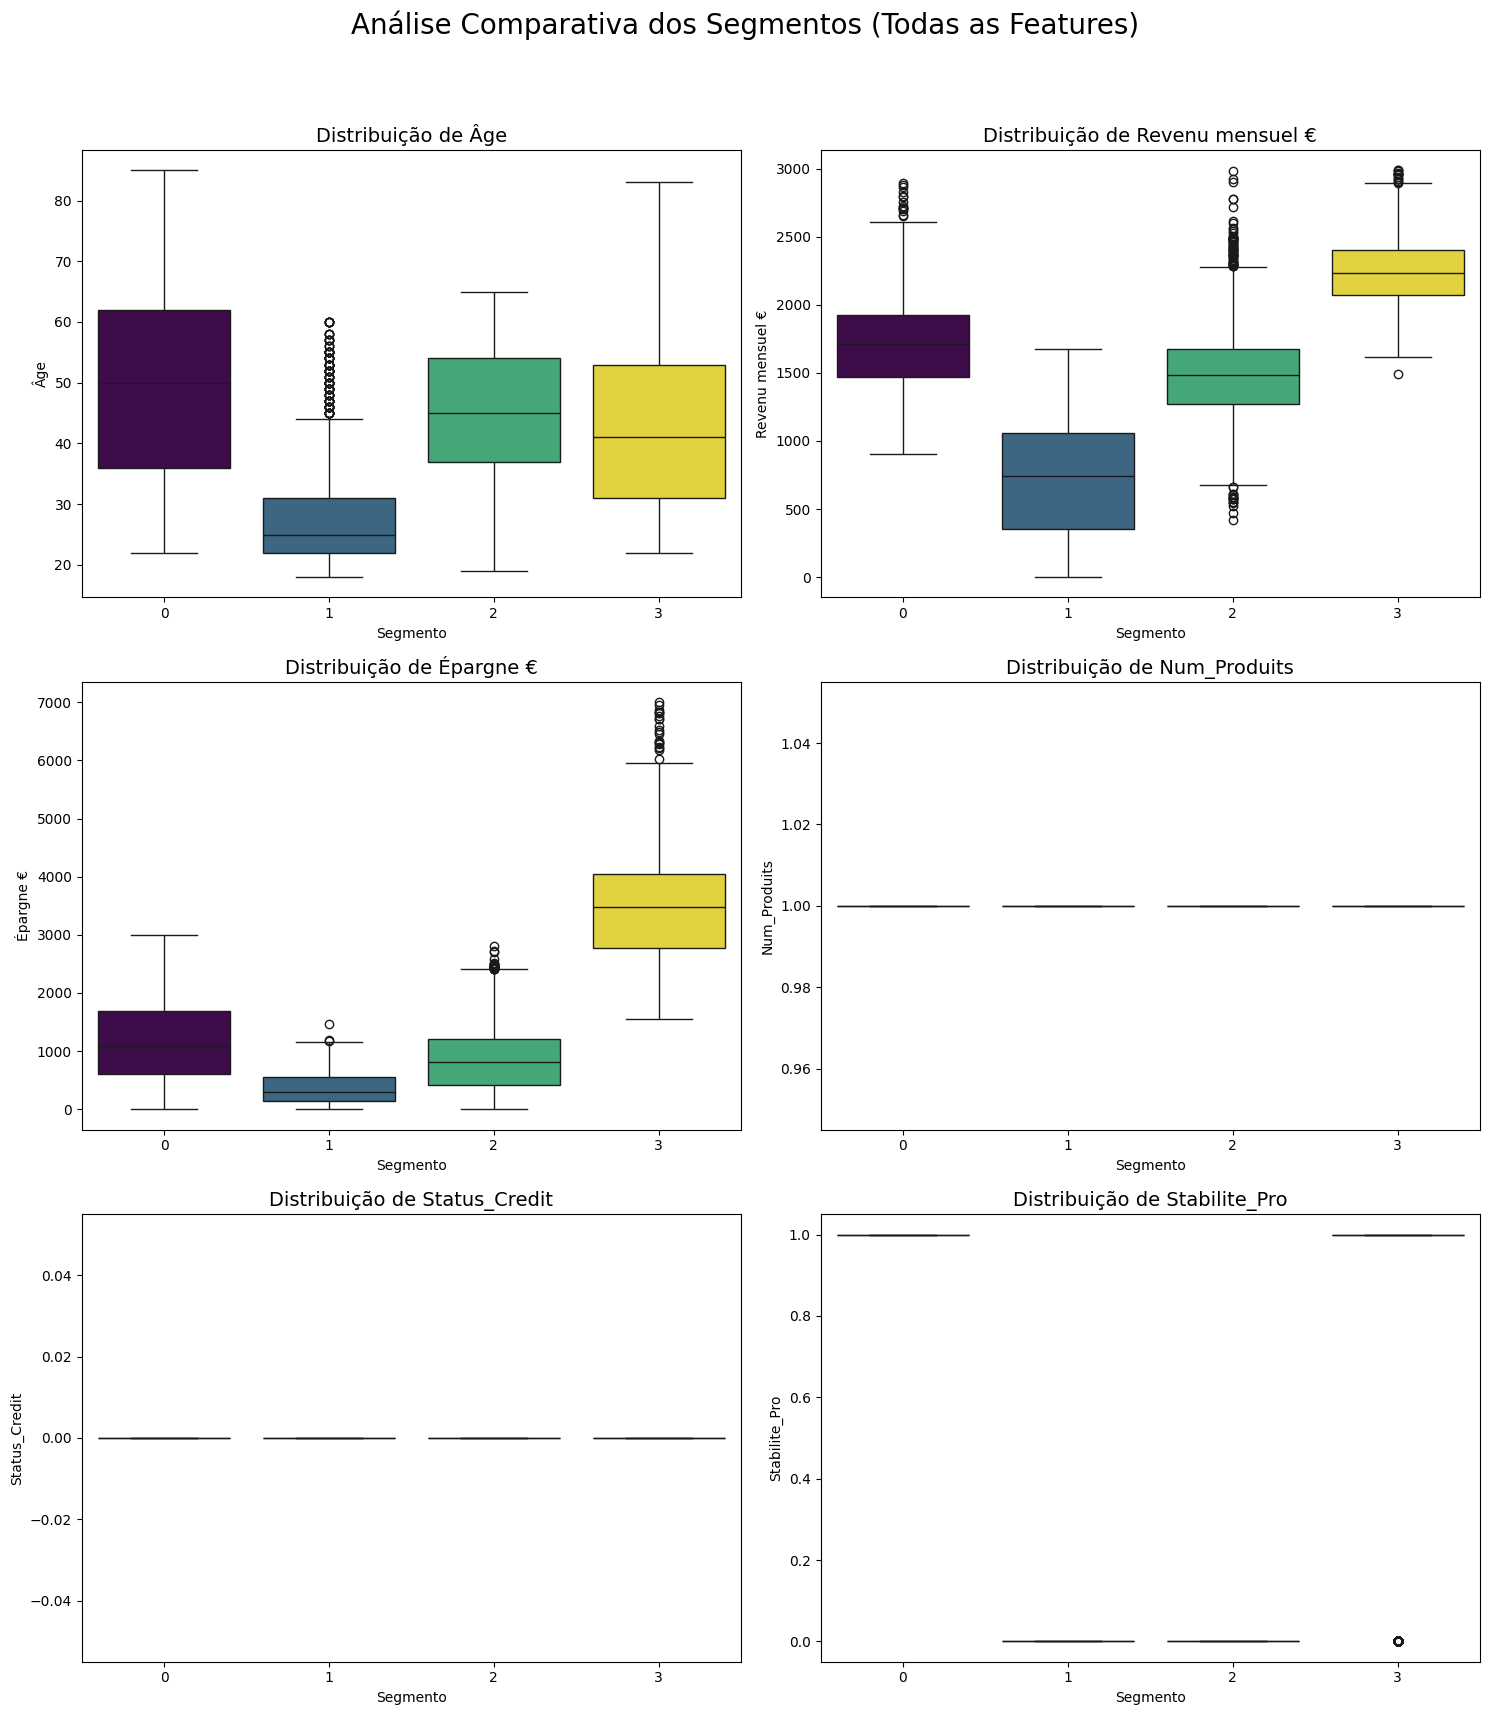

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Lista completa com as 6 variáveis utilizadas no modelo
features_plot = ['Âge', 'Revenu mensuel €', 'Épargne €', 'Num_Produits', 'Status_Credit', 'Stabilite_Pro']

# 2. Configurar a área de desenho para 6 gráficos (3x2)
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.suptitle('Análise Comparativa dos Segmentos (Todas as Features)', fontsize=20)

# 3. Loop corrigido para evitar os avisos (FutureWarning)
for i, col in enumerate(features_plot):
    row, ax_col = i // 2, i % 2
    
    # Adicionamos hue='Segmento' e legend=False para seguir o novo padrão do Seaborn
    sns.boxplot(x='Segmento', y=col, data=df, ax=axes[row, ax_col], 
                hue='Segmento', palette='viridis', legend=False)
    
    axes[row, ax_col].set_title(f'Distribuição de {col}', fontsize=14)
    axes[row, ax_col].set_xlabel('Segmento')
    axes[row, ax_col].set_ylabel(col)

# 4. Ajustar layout para não sobrepor os títulos
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('boxplots_completos.png', dpi=300)
plt.show()